In [59]:
import pandas as pd
import requests

print("Environment Ready 🚀")


Environment Ready 🚀


In [60]:
import pandas as pd

drivers = pd.read_csv("../data/drivers.csv")
results = pd.read_csv("../data/results.csv")
races = pd.read_csv("../data/races.csv")

drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [61]:
df = results.merge(drivers, on="driverId")
df = df.merge(races, on="raceId")

df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,18,1,1,22,1,1,1,1,10.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,18,2,2,3,5,2,2,2,8.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,18,3,3,7,7,3,3,3,6.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,18,4,4,5,11,4,4,4,5.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [62]:
df['driver_name'] = df['forename'] + " " + df['surname']

In [63]:
driver_stats = df.groupby('driver_name').agg({
    'positionOrder': ['mean', 'std'],
    'points': 'sum'
})

driver_stats.columns = ['avg_position', 'consistency', 'total_points']

driver_stats = driver_stats.sort_values('total_points', ascending=False)

driver_stats.head(10)

,avg_position,consistency,total_points
driver_name,,,
Lewis Hamilton,5.019663,5.551009,4820.5
Sebastian Vettel,7.093333,6.405836,3098.0
Max Verstappen,5.645933,5.997515,2912.5
Fernando Alonso,8.492574,6.043469,2329.0
Kimi Räikkönen,8.491477,6.170413,1873.0
Valtteri Bottas,8.967611,5.997879,1788.0
Nico Rosberg,8.252427,6.254315,1594.5
Sergio Pérez,9.332155,5.465812,1585.0
Michael Schumacher,6.879870,7.072577,1566.0


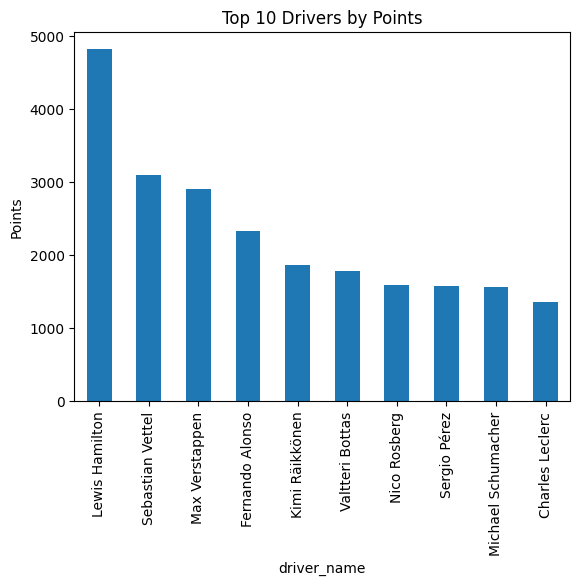

In [64]:
import matplotlib.pyplot as plt

top = driver_stats.head(10)

top['total_points'].plot(kind='bar')
plt.title("Top 10 Drivers by Points")
plt.ylabel("Points")
plt.show()

In [65]:
consistent = driver_stats.sort_values('consistency').head(10)
consistent

,avg_position,consistency,total_points
driver_name,,,
Chris Lawrence,11.000000,0.000000,0.0
Naoki Hattori,32.000000,0.000000,0.0
George Abecassis,17.000000,0.000000,0.0
Giovanna Amati,30.000000,0.000000,0.0
Enrico Bertaggia,38.833333,0.408248,0.0
Divina Galica,27.666667,0.577350,0.0
Jacques Villeneuve Sr.,27.666667,0.577350,0.0
Eddie Keizan,13.333333,0.577350,0.0
Pedro Chaves,33.615385,0.650444,0.0


In [66]:
best = driver_stats.sort_values('total_points', ascending=False).head(10)
best

,avg_position,consistency,total_points
driver_name,,,
Lewis Hamilton,5.019663,5.551009,4820.5
Sebastian Vettel,7.093333,6.405836,3098.0
Max Verstappen,5.645933,5.997515,2912.5
Fernando Alonso,8.492574,6.043469,2329.0
Kimi Räikkönen,8.491477,6.170413,1873.0
Valtteri Bottas,8.967611,5.997879,1788.0
Nico Rosberg,8.252427,6.254315,1594.5
Sergio Pérez,9.332155,5.465812,1585.0
Michael Schumacher,6.879870,7.072577,1566.0


In [67]:
hidden = driver_stats[
    (driver_stats['avg_position'] < 10) & 
    (driver_stats['total_points'] < 100)
].sort_values('avg_position')

hidden.head(10)

,avg_position,consistency,total_points
driver_name,,,
Dorino Serafini,2.000,NaN,3.0
George Amick,2.000,NaN,6.0
Lee Wallard,3.500,3.535534,9.0
Luigi Fagioli,4.375,4.438066,32.0
Eric Thompson,5.000,NaN,2.0
Oscar Gálvez,5.000,NaN,2.0
Joie Chitwood,5.000,NaN,1.0
Óscar González,6.000,NaN,0.0
Charles Pozzi,6.000,NaN,0.0


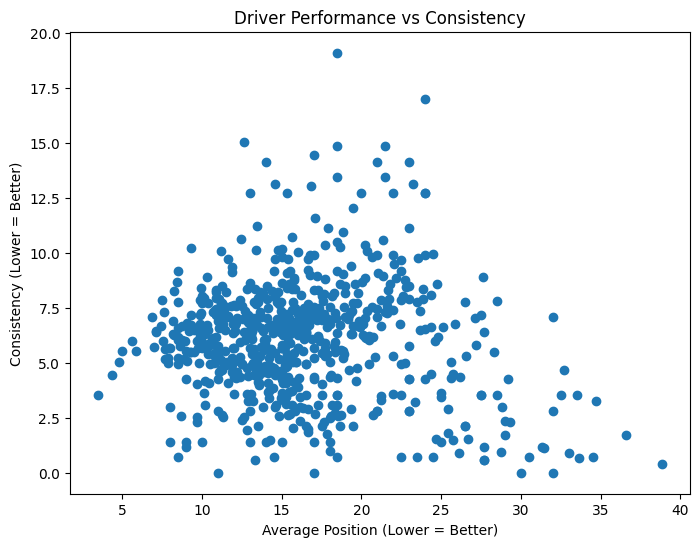

In [68]:
plt.figure(figsize=(8,6))

plt.scatter(driver_stats['avg_position'], driver_stats['consistency'])

plt.xlabel("Average Position (Lower = Better)")
plt.ylabel("Consistency (Lower = Better)")
plt.title("Driver Performance vs Consistency")

plt.show()

In [ ]:
Key Insights:

1. Drivers with low average position and low consistency are the most reliable performers.

2. Some drivers score high points but show high variability, indicating aggressive performance.

3. Hidden performers exist who maintain strong average positions but lack points due to team limitations.

4. Consistency plays a critical role in championship success, not just race wins.